# Class conditioning

What the class label controls, probed on a trained checkpoint.

`UNet(num_classes=C)` embeds the label and adds it to `temb`, on the same footing
as `t`. The embedding has `C + 1` rows — index `C` is a null label, reserved and
left untrained so classifier-free guidance can reuse these weights. `Conditioned(net, y)`
freezes `y` back into the `(x, t) -> eps` interface the samplers call.

**Run the setup cell once, then any probe below on its own.**


In [11]:
# --- setup: imports, checkpoint, samplers, helpers. Run this once. ---
%load_ext autoreload
%autoreload 2
# edits to unet.py / ddim.py land without a kernel restart. Structural changes to
# a class __init__ do NOT reach objects already built, so re-run this cell after
# those -- it rebuilds net from the checkpoint anyway.

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torchvision import datasets, transforms
from torchvision.utils import make_grid

from ddim import DDIMSampler
from forward_process import ForwardProcess
from unet import Conditioned, UNet
from utils import repo_root

dev = "cuda" if torch.cuda.is_available() else "cpu"

# a run folder under artifacts/; set RUN = None to fall back to the newest one
RUN = "cond_2026-09-09_11-42-46"
# RUN = None
ART = repo_root() / "artifacts"
CKPT = (
    ART / RUN / "ckpt.pt"
    if RUN
    else max(ART.glob("*/ckpt.pt"), key=lambda p: p.stat().st_mtime)
)
assert CKPT.exists(), (
    f"no checkpoint at {CKPT} -- runs: {sorted(p.name for p in ART.iterdir())}"
)
ck = torch.load(CKPT, map_location=dev)
C = ck.get("num_classes")
assert C, f"{CKPT} is unconditional -- train with: python main.py --num-classes 10"

fp = ForwardProcess().to(dev)
fp.load_state_dict(ck["fp"])
net = UNet(num_classes=C).to(dev)
net.load_state_dict(ck["net"])
net.eval()

# eta=0: sampling is a deterministic function of (x_T, y), which is what makes
# holding x_T fixed a controlled experiment
smp = DDIMSampler(fp, steps=50).to(dev)

ds = datasets.MNIST(
    root=repo_root() / "data",
    train=True,
    transform=transforms.Compose(
        [transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]
    ),
)


@torch.no_grad()
def sample_from(xT, y):
    """DDIM from a GIVEN x_T instead of a fresh draw, so x_T is a variable you set."""
    x = xT
    for i in range(smp.steps):
        x = smp.step(Conditioned(net, y), x, i)
    return x


def show(x, nrow, title="", scale=0.4):
    """nrow is images PER row -- a column count, not a row count."""
    g = make_grid(x.cpu(), nrow=nrow, normalize=True, value_range=(-1, 1), padding=2)
    plt.figure(figsize=(nrow * scale, x.shape[0] / nrow * scale))
    plt.imshow(g.permute(1, 2, 0))
    plt.axis("off")
    if title:
        plt.title(title, fontsize=9)
    plt.show()


print(f"{CKPT.parent.name}   classes {C}   device {dev}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
cond_2026-09-09_11-42-46   classes 10   device cuda


## Probe 1 — same `x_T`, every label

`x_T` is the pure-noise image the sampler starts from: a real `[1, 28, 28]` tensor
of Gaussian numbers, not an RNG seed. Sampling walks it backwards to `x_0`.

**Shared `x_T`** means the same tensor is reused across a row:

```python
noise = torch.randn(8, 1, 28, 28)       # 8 distinct starting points
xT = noise.repeat_interleave(C, dim=0)  # each repeated C times, consecutively
y  = torch.arange(C).repeat(8)          # 0..9, 0..9, ...
```

Element `r*C + c` gets `noise[r]` and label `c`, so every cell in row `r` began
from the identical starting noise and the only thing changing along that row is `y`.

Why bother: with `eta=0` the output is a pure function of `(x_T, y)`. Fixing `x_T`
leaves exactly one variable, so any difference across a row is caused by the label
and nothing else. If each cell drew its own noise you could not tell a label effect
from a noise effect, and the grid would prove nothing about conditioning.


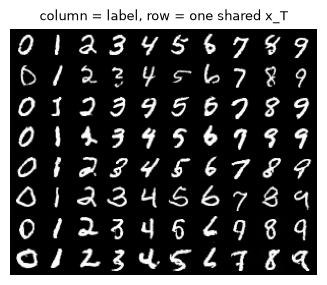

In [12]:
ROWS = 8
torch.manual_seed(7)
noise = torch.randn(ROWS, 1, 28, 28, device=dev)

xT = noise.repeat_interleave(C, dim=0)  # row r: one x_T, held fixed
y = torch.arange(C, device=dev).repeat(ROWS)  # col c: label c
show(sample_from(xT, y), nrow=C, title="column = label, row = one shared x_T")

**Columns hold identity.** Read down a column: different-looking 3s, all
unmistakably 3s. That is `y` doing its job.

**Rows hold style.** Read across a row: stroke weight and slant persist through
all ten digits. Since `y` was the only variable, that style must be carried by
`x_T` — it behaves like a latent style code. `x_T` decides _how_ the digit is
written, `y` decides _which_ digit. Nothing in the loss asked for that split; it
is a property of the learned map, and holding `x_T` fixed is what isolates it.


## Probe 2 — the reserved null label

Index `C` exists in the embedding but never received a gradient: every training
batch passes a real label in `0..C-1`. Adding it as one more column shows what an
untrained conditioning vector produces.


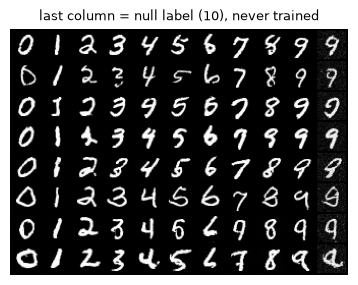

In [13]:
cols = C + 1  # ...plus the null label
xT = noise.repeat_interleave(cols, dim=0)
y = torch.arange(cols, device=dev).repeat(ROWS)
show(
    sample_from(xT, y),
    nrow=cols,
    title=f"last column = null label ({C}), never trained",
)

The null column is grey mush — correct, and useful. That row of `label_emb` is
still at its random init.

It is also why classifier-free guidance cannot skip label dropout. CFG computes

```
eps = eps_uncond + w * (eps_cond - eps_uncond)
```

If `eps_uncond` comes from an untrained null embedding it is noise, and the
formula extrapolates _away_ from noise, amplified by `w`. Training with p≈0.1
dropout is what turns this column into a real unconditional model. Re-running this
probe is the check: the null column should become plausible digits of no
particular class.


## Probe 3 — does `y` actually carry information?

The grids are read by eye. This is the number behind them: score the _same_ `x_t`
with the right label and with a wrong one. A label that is wired up but ignored —
added to `temb` and then normalised away, say — scores the two identically.


In [14]:
x0 = torch.stack([ds[i][0] for i in range(256)]).to(dev)
yc = torch.tensor([ds[i][1] for i in range(256)], device=dev)


def scored(lo, hi, draws=20):
    """eps-MSE with the true label vs a wrong one, for t drawn from [lo, hi)."""
    right = wrong = 0.0
    with torch.no_grad():
        for _ in range(draws):  # average over t and noise; one draw is far too noisy
            t = torch.randint(lo, hi, (x0.shape[0],), device=dev)
            eps = torch.randn_like(x0)
            xt = fp.q_sample(x0, t, eps)
            right += F.mse_loss(net(xt, t, yc), eps).item()
            wrong += F.mse_loss(net(xt, t, (yc + 1) % C), eps).item()
    return right / draws, wrong / draws


torch.manual_seed(0)
print(f"{'t range':>11}  {'right':>7}  {'wrong':>7}   penalty")
for lo in range(0, fp.T, 200):
    r, w = scored(lo, lo + 200)
    print(f"{lo:4d}-{lo + 200:<6d}  {r:7.4f}  {w:7.4f}   {w / r:5.2f}x")
r, w = scored(0, fp.T)
print(f"{'all t':>11}  {r:7.4f}  {w:7.4f}   {w / r:5.2f}x")

    t range    right    wrong   penalty
   0-200      0.0685   0.0703    1.03x
 200-400      0.0253   0.0366    1.44x
 400-600      0.0109   0.0223    2.04x
 600-800      0.0020   0.0034    1.73x
 800-1000     0.0003   0.0004    1.21x
      all t   0.0211   0.0266    1.26x


The penalty peaks in the **middle** of the chain, not at the end — which is not
the obvious guess.

- **low `t`** (~1.0x) — `x_t` is still legible, so the model reads the digit off
  its own input and the label is redundant. Lying about it costs nothing.
- **mid `t`** (the peak) — enough of `x0` is destroyed that identity has to come
  from `y`, but enough structure remains that getting it wrong is expensive. This
  is where conditioning does its work.
- **high `t`** — the penalty falls back. At `t≈900`, `sqrt(ᾱ)` is 0.016, so
  `x_t ≈ eps` and the best available prediction is close to _copy the input_ — a
  job no label can help or spoil much.

Worth noticing in the `right` column on its own: eps-MSE is **largest at low `t`
and smallest at high `t`**, by two orders of magnitude. The usual intuition — that
high `t` is the hard, irreducible part dragging the average up — is backwards here.
High `t` is the easy region precisely because the answer is nearly the input;
low `t` is where `1/sqrt(1-ᾱ)` amplifies any error in the implied `x0`.

That is roadmap item 1 in miniature. Caveat before building on the shape: this is
one model, scored on 256 images it was _trained_ on, so it says nothing about
generalisation — a held-out split may put the low-`t` numbers somewhere else.


## Probe 4 — the training grid, for contrast

`main.py` writes a grid every epoch with the opposite layout, and mixing the two
up is easy. Same helper, transposed meaning; the only difference is
`repeat_interleave` vs `repeat`.

|            | `main.py` grid                        | probes above                 |
| ---------- | ------------------------------------- | ---------------------------- |
| class runs | down the **rows**                     | across the **columns**       |
| noise      | independent per cell                  | **shared** `x_T` along a row |
| built with | `repeat_interleave`, `nrow=per_class` | `repeat`, `nrow=C`           |

It answers a different question: _does each class look right_, rather than _what
does the label control_.


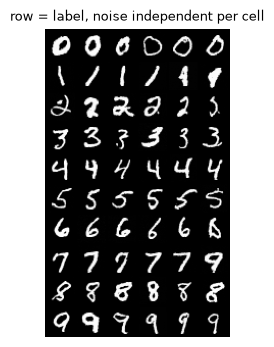

In [15]:
per_class = 6
y = torch.arange(C, device=dev).repeat_interleave(per_class)  # label-major
xT = torch.randn(y.shape[0], 1, 28, 28, device=dev)  # independent per cell
show(
    sample_from(xT, y), nrow=per_class, title="row = label, noise independent per cell"
)